# Risk assessment for airport infrastructure

- A workflow from the CLIMAAX [Handbook](https://handbook.climaax.eu/) and [MULTI_HAZARD](https://github.com/CLIMAAX/MULTI_HAZARD) GitHub repository.
- See our [how to use risk workflows](https://handbook.climaax.eu/notebooks/workflows_how_to.html) page for information on how to run this notebook.

The impact of the single hazard (e.g. extreme precipitation, heatwaves) can be evaluated on the different assets of the infrastructure, for example on the terminal, runway, taxiways, parking areas etc.

In this notebook, the calculation of risk associated with the variable under examination will be shown. Pandas dataframes will be presented which, in the example, show nine airports - the operator will need to modify the list of airports by adding/modifying names.
The same concept applies to exposure and vulnerability indicators - indicators will be presented that can be expanded or modified by the user.
The only mandatory thing is that the framework was conceptualized for at least two airports.

## Preparation work

### Import libraries

In [1]:
import os

import matplotlib.pyplot as plt
import contextily as ctx
import numpy as np
import pandas as pd
import scipy.spatial
import xarray as xr

### Area of interest

Specify the same name as in the the hazard assessment to continue with the results of these notebooks.

In [2]:
region_name = 'IT'

### Path configuration

In [3]:
# Path to the folder containing all indicator data
indicators_path = f'data_{region_name}/indicators/uerra'

## Step 1: Define the airports

List the airports and their coordinates.

In [4]:
airports = [
    'Milano Malpensa', 'Milano Linate', 'Bergamo Orio al Serio',
    'Roma Fiumicino', 'Roma Ciampino', 'Napoli Capodichino',
    'Palermo Punta Raisi', 'Catania Fontanarossa', 'Cagliari Elmas'
]

:::{tip}
Enter the locations of your choice here.
At least two locations must be defined for the methodology to work.
:::

In [5]:
def to_dataframe(dct):
    idx = pd.Index(airports, name='airport')
    return pd.DataFrame(dct, index=idx, dtype=float)

In [6]:
# List coordinates in the order of the locations from above (°N, °E)
coords = to_dataframe({
    'latitude': [45.63, 45.45, 45.67, 41.80, 41.80, 40.88, 38.18, 37.47, 39.25],
    'longitude': [8.73, 9.28, 9.71, 12.25, 12.59, 14.29, 13.10, 15.07, 9.06]
})

# Check that the coordinates are correctly associated with the airports
coords

,latitude,longitude
airport,,
Milano Malpensa,45.63,8.73
Milano Linate,45.45,9.28
Bergamo Orio al Serio,45.67,9.71
Roma Fiumicino,41.80,12.25
Roma Ciampino,41.80,12.59
Napoli Capodichino,40.88,14.29
Palermo Punta Raisi,38.18,13.10
Catania Fontanarossa,37.47,15.07
Cagliari Elmas,39.25,9.06


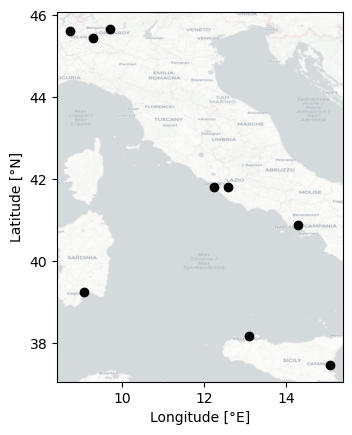

In [7]:
fig, ax = plt.subplots(1, 1)
ax.scatter(coords.longitude, coords.latitude, color='k')
ax.set_xlabel('Longitude [°E]')
ax.set_ylabel('Latitude [°N]')
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.CartoDB.Positron, attribution=False)

## Step 2: Component normalization

The aim of normalization processes is to transform the values of these indicators, which are measured at different scales and in different units, into comparable values considered on a common scale ([Master Adapt, 2018](https://masteradapt.eu/wordpress/wp-content/uploads/2018/03/MA-linee-guida-A1-1.pdf)).

We use the Min-Max method to transform all values to scores in a range from 0 to 1, where the value 0 represents the optimal level, while the value 1 reflects the most critical estimates:

In [8]:
def normalize_columns(df):
    return (df - df.min()) / (df.max() - df.min())

## Step 3: Hazard

Load the hazard indicator data produced by the hazard assessment notebook and extract the information for the airport locations specified above.

In [9]:
def load_all(files):
    '''Load data based on a name-to-file mapping'''
    das = []
    for name, file in files.items():
        path = os.path.join(indicators_path, file)
        if name == '*':
            ds = xr.open_dataset(path)
            das.extend(ds.data_vars.values())
        else:
            da = xr.open_dataarray(path)
            das.append(da.rename(name))
    return xr.merge(das, compat='override')

def extract_points(ds, points):
    '''Extract data from the dataset for a set of points'''
    grid = np.column_stack([
        ds['latitude'].values.flatten(),
        ds['longitude'].values.flatten()
    ])
    tree = scipy.spatial.cKDTree(grid)
    _, closest_idx = tree.query(coords.values, k=1)
    idx_y, idx_x = np.unravel_index(closest_idx, ds['latitude'].shape)
    return (
        ds
        .isel(
            x=xr.DataArray(idx_x, dims='airport'),
            y=xr.DataArray(idx_y, dims='airport')
        )
        # Clean-up table: remove coordinates not needed (extend as required)
        .drop_vars(['latitude', 'longitude', 'x', 'y', 'height', 'time', 'quantile'], errors='ignore')
        .assign_coords({'airport': coords.index})
        .to_dataframe()
    )

### Temperature

In [10]:
data_temp = load_all({
    'Days Above 35°C': 'Temp_DaysAbove35.nc',
    'Days Above 40°C': 'Temp_DaysAbove40.nc',
    'Days Above 45°C': 'Temp_DaysAbove45.nc',
})

In [11]:
indicators_temp = extract_points(data_temp, coords)
indicators_temp

,Days Above 35°C,Days Above 40°C,Days Above 45°C
airport,,,
Milano Malpensa,0.000000,0.000000,0.0
Milano Linate,0.533333,0.000000,0.0
Bergamo Orio al Serio,0.433333,0.000000,0.0
Roma Fiumicino,0.166667,0.000000,0.0
Roma Ciampino,3.400000,0.000000,0.0
Napoli Capodichino,3.433333,0.000000,0.0
Palermo Punta Raisi,1.266667,0.100000,0.0
Catania Fontanarossa,8.933333,1.133333,0.2
Cagliari Elmas,6.700000,0.266667,0.0


Combine the indicator columns into a single indicator for the temperature hazard by taking the mean over all columns at each location.

<Axes: title={'center': 'Hazard: Temperature'}, ylabel='airport'>

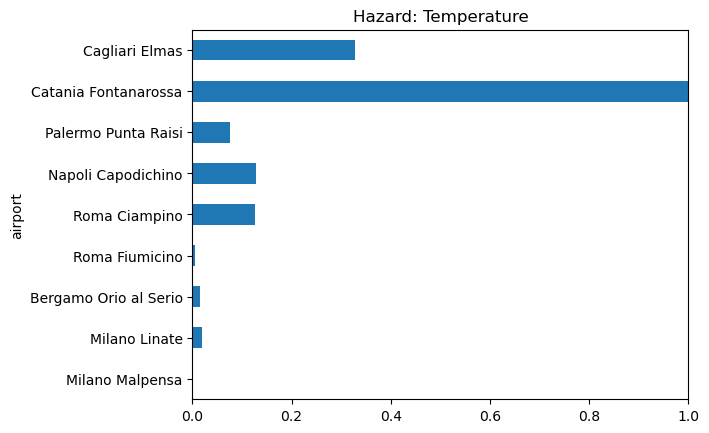

In [12]:
hazard_temp = normalize_columns(indicators_temp).mean(axis=1, skipna=True)

# Quick bar chart of the temperature hazard indicator
hazard_temp.plot.barh(title='Hazard: Temperature', xlim=(0, 1))

### Precipitation

Repeat the steps for the precipitation indicators:

In [13]:
data_precip = load_all({
    '*': 'Precip_return_levels_gumbel.nc',
    'Precip_P99': 'Precip_P99.nc',
    'Precip_P999': 'Precip_P999.nc'
})

indicators_precip = extract_points(data_precip, coords)
indicators_precip

,return_period_2_y,return_period_5_y,return_period_10_y,return_period_20_y,return_period_30_y,return_period_50_y,return_period_100_y,return_period_150_y,return_period_200_y,return_period_500_y,Precip_P99,Precip_P999
airport,,,,,,,,,,,,
Milano Malpensa,77.240410,97.857880,111.508438,124.602386,132.135010,141.551163,154.251877,161.657974,166.906250,183.601303,48.059845,94.042389
Milano Linate,56.678417,70.069450,78.935478,87.439987,92.332420,98.448204,106.697311,111.507561,114.916313,125.759735,34.706484,63.180023
Bergamo Orio al Serio,49.203640,59.805862,66.825455,73.558823,77.432358,82.274467,88.805618,92.614090,95.312943,103.898109,33.550508,51.886977
Roma Fiumicino,50.875408,69.739494,82.229156,94.209549,101.101570,109.716927,121.337532,128.113785,132.915726,148.190964,27.939688,60.487923
Roma Ciampino,43.058388,56.674309,65.689232,74.336563,79.311157,85.529648,93.917290,98.808327,102.274323,113.299850,26.153749,52.537727
Napoli Capodichino,60.708721,85.161652,101.351616,116.881424,125.815338,136.983170,152.046585,160.830429,167.055054,186.855865,35.195312,84.431564
Palermo Punta Raisi,56.251366,81.191704,97.704376,113.543732,122.655724,134.046158,149.409836,158.368759,164.717453,184.912949,35.360001,88.106552
Catania Fontanarossa,58.424789,85.944069,104.164230,121.641449,131.695663,144.263901,161.216263,171.101578,178.106750,200.390549,26.499609,81.429756
Cagliari Elmas,32.551186,44.475163,52.369877,59.942673,64.299118,69.744881,77.090256,81.373528,84.408836,94.064301,17.672501,37.748158


<Axes: title={'center': 'Hazard: Precipitation'}, ylabel='airport'>

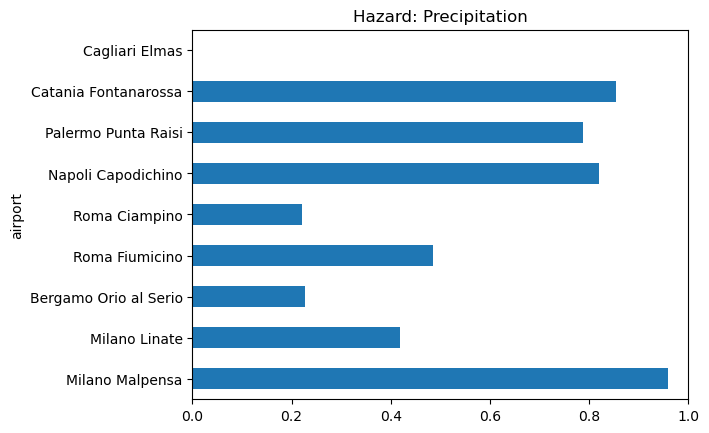

In [14]:
hazard_precip = normalize_columns(indicators_precip).mean(axis=1, skipna=True)

# Quick bar chart of the precipitation hazard indicator
hazard_precip.plot.barh(title='Hazard: Precipitation', xlim=(0, 1))

## Step 4: Exposure

The various airports components, divided into landside and airside areas, were considered as exposed samples in accordance with [De Vivo et al. (2022)](https://doi.org/10.1007/s11069-021-05066-0).

The **air side components** include the structures used for the movement of aircraft, such as runways, taxiways, tower, and aprons:

| Air side  | Unit of measurement |
|-----------|---------------------|
| Runways   | Area [m²]           | 
| Taxiways  | Area [m²]           | 
| Tower     | Height [m]          | 
| Apron     | Area [m²]           | 


The **land side components** refer to the public access areas such as offices, terminals, airports access systems and parking areas:

| Land side                    | Unit of measurement |
|------------------------------|---------------------|
| Terminal                     | Area [m²]           | 
| Offices and other buildings  | Area [m²]           | 
| Airport accesses systems     | Area [m²]           | 
| Carparks                     | Number              | 

Define the values for each indicator and airport: (insert `None` where data is not available)

In [15]:
# Specify the values in the order of the locations defined above
air_land_side_components = to_dataframe({
    'Runways': [470400, 159742, 145530, 396000, 9900, 118260, 292650, 109575, 126000],
    'Taxiways': [250.5, 156, 183, 300, 301, 99, 368, 159, 604],
    'Tower': [80, 47, 30, 56, 60, 40, 25, 12, 28],
    'Apron': [1319000, 387000, 190000, 797250, None, 200000, 148000, 180000, 156000],
    'Terminals': [315000, 85050, 53025, 354300, 20950, 30700, 35400, 43310, 41290],
    'Offices_and_other_buildings': [26715, 13527, 7075, 29520, 5950, 1915, 4180, 6920, 5030],
    'Airport_accesses_systems': [31660, None, None, None, None, None, None, None, None],
    'Carparks': [15000, 3000, 8000, 20100, 1220, 1500, 1364, 1800, 2133]
})

# Check that values are associated correctly to the locations
air_land_side_components

,Runways,Taxiways,Tower,Apron,Terminals,Offices_and_other_buildings,Airport_accesses_systems,Carparks
airport,,,,,,,,
Milano Malpensa,470400.0,250.5,80.0,1319000.0,315000.0,26715.0,31660.0,15000.0
Milano Linate,159742.0,156.0,47.0,387000.0,85050.0,13527.0,NaN,3000.0
Bergamo Orio al Serio,145530.0,183.0,30.0,190000.0,53025.0,7075.0,NaN,8000.0
Roma Fiumicino,396000.0,300.0,56.0,797250.0,354300.0,29520.0,NaN,20100.0
Roma Ciampino,9900.0,301.0,60.0,NaN,20950.0,5950.0,NaN,1220.0
Napoli Capodichino,118260.0,99.0,40.0,200000.0,30700.0,1915.0,NaN,1500.0
Palermo Punta Raisi,292650.0,368.0,25.0,148000.0,35400.0,4180.0,NaN,1364.0
Catania Fontanarossa,109575.0,159.0,12.0,180000.0,43310.0,6920.0,NaN,1800.0
Cagliari Elmas,126000.0,604.0,28.0,156000.0,41290.0,5030.0,NaN,2133.0


As for the hazard, we normalize each component and combine them into a single indicator for exposure by taking the mean over all components for each location.

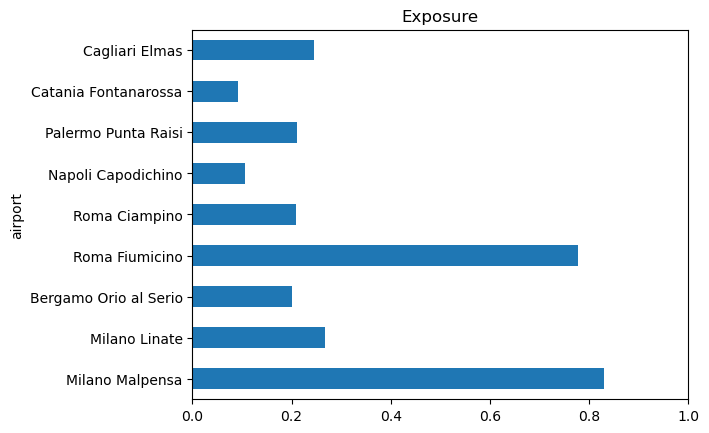

In [16]:
air_land_side_normalized = normalize_columns(air_land_side_components)

# Combine into a single indicator
exposure = air_land_side_normalized.mean(axis=1, skipna=True)

# Quick bar plot of the exposure indicator
ax = exposure.plot.barh(title='Exposure', xlim=(0, 1))

## Step 5: Vulnerability

Vulnerability reflects “the propensity or predisposition of a system to be adversely affected. It encompasses a variety of concepts and elements including sensitivity or susceptibility to harm and lack of capacity to cope and adapt opportunities, or to respond to consequences” (IPCC, 2022).

Vulnerability is composed of **sensitivity** and **adaptive capacity**.

### Sensitivity

Sensitivity is intended as the degree to which the system is (positively or negatively) affected by climate variability or climate change. 

| Indicator                     |Unit of measurement                |
|-------------------------------|-----------------------------------|
| Soil Sealing                  | Area [%]                          | 
| Passenger                     | Number                            | 
| Building in bad condition     | Number or Absence/Presence        | 
| Age building                  | Age                               | 
| Air traffic                   | Number                            |
| Parking accesses              | Number                            |
| Staff work outside airport    | Number                            |
| Underground infrastructures   | Number (or Area)                  |
| Flooded areas                 | Number (or %)                     |

Define the sensitivity indicators and their values: (use `None` where data is not available)

In [17]:
sensitivity_indicators = to_dataframe({
    'Soil_sealing': [1235, 300, 300, 1590, 133, 217, 391, 225, 246],
    'Passengers': [27000000, 7000000, 13857257, 43532573, 5879496, 10860068, 7018087, 10223113, 4747806],
    'Buildings_bad_conditions_or_maintenance': [None, None, None, None, None, None, None, None, None],
    'Age_buildings': [73, 82, 83, 63, 105, 111, 61, 97, 84],
    'Air_traffic': [201050, 85730, 95377, 309783, 52253, 82577, 54243, 73494, 39691],
    'Parking_accesses': [None, None, None, None, None, None, None, None, None],
    'Staff_work': [1997.1, 855.9, 1044, 2363.9, 1013.1, None, 283, 183, 146],
    'Underground_infrastructures': [30300, 14700, 5700, 26250, 2250, 0, 0, 8650, 0],
    'Flooded_areas': [None, None, None, None, None, None, None, None, None],
})

sensitivity_normalized = normalize_columns(sensitivity_indicators)
sensitivity_normalized

,Soil_sealing,Passengers,Buildings_bad_conditions_or_maintenance,Age_buildings,Air_traffic,Parking_accesses,Staff_work,Underground_infrastructures,Flooded_areas
airport,,,,,,,,,
Milano Malpensa,0.756349,0.573735,NaN,0.24,0.597422,NaN,0.834618,1.000000,NaN
Milano Linate,0.114619,0.058069,NaN,0.42,0.170457,NaN,0.320078,0.485149,NaN
Bergamo Orio al Serio,0.114619,0.234872,NaN,0.44,0.206174,NaN,0.404888,0.188119,NaN
Roma Fiumicino,1.000000,1.000000,NaN,0.04,1.000000,NaN,1.000000,0.866337,NaN
Roma Ciampino,0.000000,0.029179,NaN,0.88,0.046510,NaN,0.390955,0.074257,NaN
Napoli Capodichino,0.057653,0.157594,NaN,1.00,0.158783,NaN,NaN,0.000000,NaN
Palermo Punta Raisi,0.177076,0.058535,NaN,0.00,0.053878,NaN,0.061770,0.000000,NaN
Catania Fontanarossa,0.063143,0.141172,NaN,0.72,0.125154,NaN,0.016682,0.285479,NaN
Cagliari Elmas,0.077557,0.000000,NaN,0.46,0.000000,NaN,0.000000,0.000000,NaN


### Adaptative capacity

These indicators are defined by the classes reported below and included in [De Vivo et al. (2022)](https://doi.org/10.1007/s11069-021-05066-0).
If the indicator is present or absent, its value will be 0.9 or 0.1, respectively.

#### Risk awareness: Initiatives for mitigation to climate change

1. Adherence to "NetZero2050" Programme (neutrality 3+)
2. Certification ISO 50001 and initiatives of "energy saving"
3. Neutrality 3+ Airport carbon accreditation
4. Neutrality 4+ Airport carbon accreditation; EP-100 intelligent use of energy from "The Climate Group"- Certification ISO 50001
5. Level 2 Airport carbon accreditation, environmental improvement program
6. Commitment to obtaining certfiication

#### Initiatives for adaptation to climate change

- **Efficient drainage system**
  1. Present

- **Insurance policy for extreme events**
  1. Absent

- **Monitoring and alarm system**
  1. Present
  2. Present (but alert wind shear)
  2. Absent

- **Bioinfiltration and permeable pavements**
  1. Present
  2. Absent

- **Risk awareness (and initiatives of mitigation)**
  1. Risk management framework 
  2. Development of local (Urban) climate change mitigation and adaptation strategies
  3. Sustainability Report 2019
  4. gesap environmental report
  5. Absent

#### Guidelines for adaptation plan to climate change

  1. Plan (PACC) and regional strategy for adaptation to climate change
  2. Regional plan under development
  3. Absent
  4. Sustainable Energy and Climate Action Plan (Covenant of Mayors)
  5. Sustainable Energy and Climate Action Plan (Covenant of Mayors) municipality of Catania
  6. Regional climate change adaptation strategy

| Class No. | Description      | Value Range | Indicator Range (0-1) |
|-----------|------------------|-------------|-----------------------|
| 1         | Optimal          | 0 - 0.2     | 0.1                   |
| 2         | Quite Positive   | 0.2 - 0.4   | 0.3                   |
| 3         | Neutral          | 0.4 - 0.6   | 0.5                   |
| 4         | Quite Negative   | 0.6 - 0.8   | 0.7                   |
| 5         | Critical         | 0.8 - 1     | 0.9                   |


Define the adaptive capacity indicators and their values: (use `None` where data is not available)

In [18]:
adaptive_indicators = to_dataframe({
    'Vegetation_zone': [None, None, None, None, None, None, None, None, None],
    'Initiatives_for_optimization_of_energy ': [0.3, 0.3, 0.3, 0.1, 0.1, 0.3, 0.5, 0.7, 0.7],
    'Initiatives_mitigation_climate_change_risk_awareness': [0.3, 0.3, 0.3, 0.1, 0.1, 0.3, 0.5, 0.7, 0.7],
    'Efficient_drainage_system': [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1],
    'Monitoring_and_alarm_system': [0.1, 0.1, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3, 0.3],
    'Bioinfiltration_and_permeable_pavements': [0.9, 0.9, 0.1, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9],
    'Green_wall': [0.1, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9],
    'Green_roof': [0.1, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9],
    'Heat_resistent_coating': [0.9, 0.9, 0.9, 0.1, 0.9, 0.9, 0.9, 0.9, 0.9],
    'Insurance_policy_for_extreme_events': [0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9, 0.9],
    'Guidelines_for_adaptation_climate_change': [0.3, 0.3, 0.3, 0.5, 0.5, 0.9, 0.3, 0.3, 0.3],
    'Evening_departures': [None, None, None, None, None, None, None, None, None]
})

# As defined in the example, the indicators are already normalized into the range [0, 1]
adaptive_normalized = adaptive_indicators
adaptive_normalized

,Vegetation_zone,Initiatives_for_optimization_of_energy,Initiatives_mitigation_climate_change_risk_awareness,Efficient_drainage_system,Monitoring_and_alarm_system,Bioinfiltration_and_permeable_pavements,Green_wall,Green_roof,Heat_resistent_coating,Insurance_policy_for_extreme_events,Guidelines_for_adaptation_climate_change,Evening_departures
airport,,,,,,,,,,,,
Milano Malpensa,NaN,0.3,0.3,0.1,0.1,0.9,0.1,0.1,0.9,0.9,0.3,NaN
Milano Linate,NaN,0.3,0.3,0.1,0.1,0.9,0.9,0.9,0.9,0.9,0.3,NaN
Bergamo Orio al Serio,NaN,0.3,0.3,0.1,0.3,0.1,0.9,0.9,0.9,0.9,0.3,NaN
Roma Fiumicino,NaN,0.1,0.1,0.1,0.3,0.9,0.9,0.9,0.1,0.9,0.5,NaN
Roma Ciampino,NaN,0.1,0.1,0.1,0.3,0.9,0.9,0.9,0.9,0.9,0.5,NaN
Napoli Capodichino,NaN,0.3,0.3,0.1,0.3,0.9,0.9,0.9,0.9,0.9,0.9,NaN
Palermo Punta Raisi,NaN,0.5,0.5,0.1,0.3,0.9,0.9,0.9,0.9,0.9,0.3,NaN
Catania Fontanarossa,NaN,0.7,0.7,0.1,0.3,0.9,0.9,0.9,0.9,0.9,0.3,NaN
Cagliari Elmas,NaN,0.7,0.7,0.1,0.3,0.9,0.9,0.9,0.9,0.9,0.3,NaN


### Vulnerability calculation

We combine the sensitivity and adaptive capacity indicators by taking the mean at each location, then calculate a single vulnerability indicator by taking the mean of these two components.

Vulnerability indicators are computed separately for each hazard, only taking into account the relevant indicators from sensitivity and adaptive capacity.

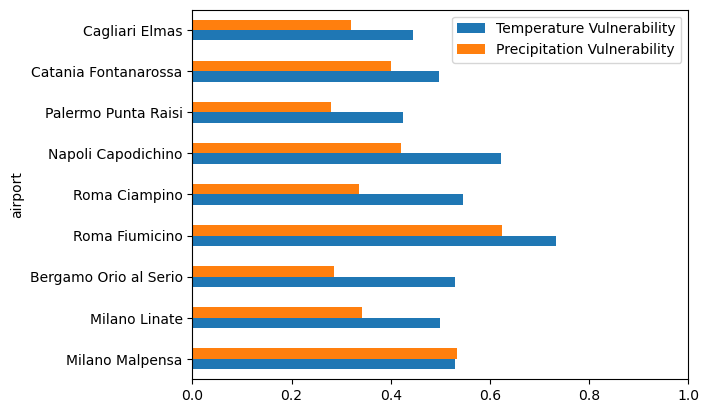

In [19]:
def calculate_vulnerability(sensitivity, adaptive_capacity, only=None):
    # Take mean of each category, then average
    return 0.5 * (
        sensitivity[[col for col in sensitivity.columns if (only is None or col in only)]].mean(skipna=True, axis=1)
        + adaptive_capacity[[col for col in adaptive_capacity.columns if (only is None or col in only)]].mean(skipna=True, axis=1)
    )

vulnerability_temp = calculate_vulnerability(sensitivity_normalized, adaptive_normalized, only={
    'Soil_sealing', 'Passengers', 'Buildings_bad_conditions_or_maintenance',
    'Age_buildings', 'Air_traffic', 'Parking_accesses', 'Staff_work',
    'Vegetation_zone', 'Initiatives_for_optimization_of_energy', 'Green_wall',
    'Green_roof', 'Heat_resistent_coating', 'Insurance_policy_for_extreme_events',
    'Guidelines_for_adaptation_climate_change', 'Evening departures'
})

vulnerability_precip = calculate_vulnerability(sensitivity_normalized, adaptive_normalized, only={
    'Soil_sealing', 'Passengers', 'Buildings_bad_conditions_or_maintenance',
    'Age_buildings', 'Air_traffic', 'Underground_infrastructures', 'Flooded_areas',
    'Vegetation_zone', 'Initiatives_mitigation_climate_change_risk_awareness',
    'Efficient_drainage_system', 'Insurance_policy_for_extreme_events',
    'Monitoring_and_alarm_system', 'Bioinfiltration_and_permeable_pavements',
    'Guidelines_for_adaptation_climate_change'
})

ax = pd.DataFrame.from_dict({
    'Temperature Vulnerability': vulnerability_temp,
    'Precipitation Vulnerability': vulnerability_precip,
}).plot.barh(xlim=(0, 1))

## Step 6: Calculate Risk

The risk (`R`) will be computed by multiplication of the three components hazard (`H`), exposure (`E`) and vulnerability (`V`):

    R = H * E * V

In [20]:
risk_table = pd.DataFrame.from_dict({
    'Temperature hazard': hazard_temp,
    'Precipitation hazard': hazard_precip,
    'Exposure': exposure,
    'Temperature Vulnerability': vulnerability_temp,
    'Precipitation Vulnerability': vulnerability_precip,
    # Calculate the risk by multiplying the components
    'Temperature risk': hazard_temp * exposure * vulnerability_temp,
    'Precipitation risk': hazard_precip * exposure * vulnerability_precip,
})

# Export the table to the data folder
risk_table.to_csv(os.path.join(indicators_path, f'risk_{region_name}.csv'))

# Show the table
risk_table

,Temperature hazard,Precipitation hazard,Exposure,Temperature Vulnerability,Precipitation Vulnerability,Temperature risk,Precipitation risk
airport,,,,,,,
Milano Malpensa,0.000000,0.958177,0.830052,0.530212,0.533417,0.000000,0.424247
Milano Linate,0.019900,0.418003,0.266326,0.498322,0.341496,0.002641,0.038017
Bergamo Orio al Serio,0.016169,0.226971,0.200527,0.530055,0.285045,0.001719,0.012973
Roma Fiumicino,0.006219,0.484378,0.776851,0.734000,0.623967,0.003546,0.234792
Roma Ciampino,0.126866,0.221027,0.208675,0.544664,0.336328,0.014419,0.015512
Napoli Capodichino,0.128109,0.820619,0.105080,0.621754,0.420736,0.008370,0.036280
Palermo Punta Raisi,0.076675,0.786895,0.210126,0.425126,0.278949,0.006849,0.046123
Catania Fontanarossa,1.000000,0.853814,0.091670,0.496615,0.400161,0.045525,0.031320
Cagliari Elmas,0.328431,0.000000,0.245209,0.443756,0.320422,0.035738,0.000000


### Visualizing the absolute risk indicators

Because the hazard, exposure and vulnerability indicators are normalized into the range 0 to 1, the risk indicator as a product of these components also lies in the range 0 to 1.
The higher its value, the larger the risk.

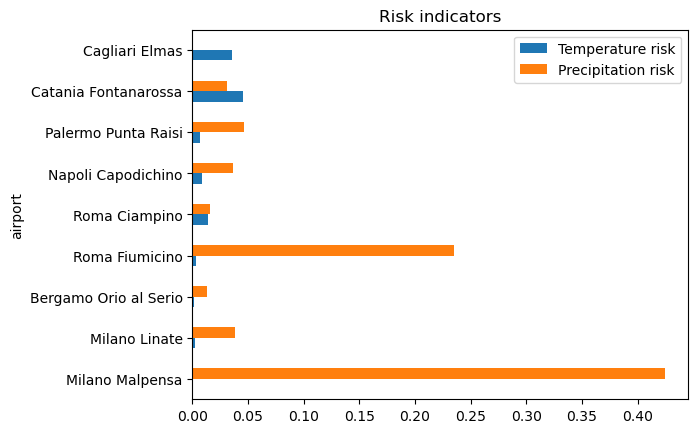

In [21]:
ax = risk_table[['Temperature risk', 'Precipitation risk']].plot.barh(title='Risk indicators')

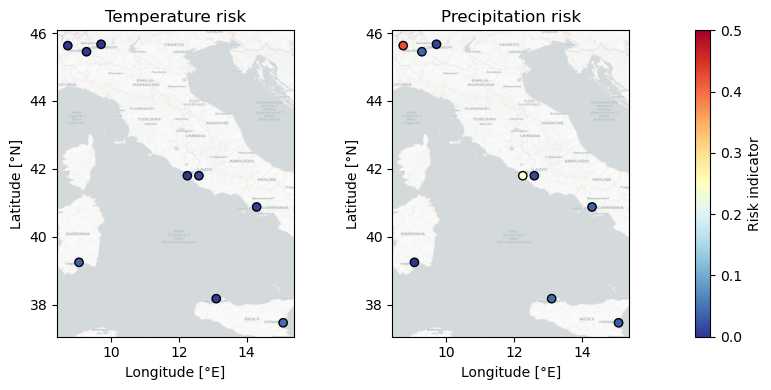

In [22]:
fig, axs = plt.subplots(1, 3, width_ratios=[20, 20, 1], figsize=(8, 4))

for ax, name in zip(axs, ['Temperature risk', 'Precipitation risk']):
    ax.set_title(name)
    sc = ax.scatter(
        coords.longitude,
        coords.latitude,
        c=risk_table[name],
        cmap='RdYlBu_r',
        vmin=0.0,  # minimum value of color scale
        vmax=0.5,  # maximum value of color scale
        edgecolor='black',
    )
    ax.set_xlabel('Longitude [°E]')
    ax.set_ylabel('Latitude [°N]')
    ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.CartoDB.Positron, attribution=False)

fig.colorbar(sc, cax=axs[2], orientation='vertical', label='Risk indicator')
fig.tight_layout()

### Classify relative risk

Evaluate the risk classes for each airport with a quantile method, classifying each airport **relative** to all other airports.

In [23]:
def classify_risk(risk, classes=['Very Low', 'Low', 'Medium', 'High', 'Very High']):
    return pd.qcut(risk, q=len(classes), labels=classes)

risk_classes = pd.DataFrame.from_dict({
    c: classify_risk(risk_table[c]) for c in ['Temperature risk', 'Precipitation risk']
})

In [24]:
def highlight_class_column(s):
    '''Color the table entries based on the risk classes'''
    colors = {
        'Very Low': 'background-color: #2c7bb6; color: white;',
        'Low': 'background-color: #abd9e9;',
        'Medium': 'background-color: #ffffbf;',
        'High': 'background-color: #fdae61;',
        'Very High': 'background-color: #d7191c; color: white;'
    }
    return [colors.get(val, '') for val in s]

risk_classes.style.apply(highlight_class_column, axis=0)

,Temperature risk,Precipitation risk
airport,,
Milano Malpensa,Very Low,Very High
Milano Linate,Low,High
Bergamo Orio al Serio,Very Low,Very Low
Roma Fiumicino,Low,Very High
Roma Ciampino,High,Low
Napoli Capodichino,High,Medium
Palermo Punta Raisi,Medium,High
Catania Fontanarossa,Very High,Low
Cagliari Elmas,Very High,Very Low


## Next steps

Options to continue with the risk assessment:

- Other hazard, exposure or vulnerability indicators can be integrated in the risk assessment following the normalisation approach as demonstrated in this notebook.
  Extend the corresponding location-specific tables created above with appropriate values to expand the scope of the risk asssessment and customise it so it reflects your priorities and interests.
- Run the risk assessment for different time periods and climate scenarios.
  Take care, however, when comparing the risk results from different periods/scenarios as the method based on normalisation provides a relative assessment of risk within each workflow application (i.e., within each scenario/period).
- Run the workflow for multiple climate model projections to obtain an estimate of uncertainty.
  A simple measure of uncertainty is the standard deviation around the mean of an ensemble of models.

:::{seealso}
Our data dashboards on [EURO-CORDEX model biases](https://handbook.climaax.eu/dashboards/bias-uncertainty/) and [climate scenarios](https://handbook.climaax.eu/dashboards/scenarios/) provide relevant information on temperature and precipitation projections for a quick estimation of projection uncertainty.
:::